# THUẬT TOÁN 1 (TT1): PHÂN ĐOẠN TIẾNG NÓI / KHOẢNG LẶNG (VAD)
## TỐI ƯU HÓA NGƯỠNG NĂNG LƯỢNG NGẮN HẠN (STE) BẰNG TÌM KIẾM NHỊ PHÂN

### 1. Cấu hình môi trường và tham số hệ thống
Khai báo thư viện toán học cơ sở (`wave`, `numpy`, `matplotlib`), nạp `IPython.display.Audio` và thiết lập tham số framing.

In [1]:
from pathlib import Path
import wave
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "TinHieuHuanLuyen").exists() and (candidate / "TinHieuKiemThu").exists():
            return candidate
    return Path.cwd()

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / "TinHieuHuanLuyen"
TEST_DIR = PROJECT_ROOT / "TinHieuKiemThu"
OUTPUT_DIR = PROJECT_ROOT / "src" / "TT1" / "output" / "mine"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình DSP chuẩn hóa
FRAME_MS = 25        # Độ dài frame (ms)
HOP_MS = 10          # Bước trượt frame (ms)
MIN_SILENCE_MS = 200 # Khoảng lặng tối thiểu (ms) để lọc khoảng lặng ảo

### 2. Đọc file âm thanh WAV (PCM 16-bit)
Đọc dữ liệu sóng âm, chuẩn hóa biên độ về khoảng `[-1, 1]`, trích xuất tần số lấy mẫu `fs` và biên độ cực đại.

In [2]:
def read_wav(wav_path):
    """Đọc file WAV 16-bit PCM, chuẩn hóa biên độ về [-1, 1], lấy fs và max biên độ."""
    with wave.open(str(wav_path), "rb") as wf:
        fs = wf.getframerate()
        samples = wf.readframes(wf.getnframes())
    signal = np.frombuffer(samples, dtype=np.int16).astype(float)
    max_amp = np.max(np.abs(signal))
    return signal / max_amp, fs, max_amp

### 3. Đọc nhãn phân đoạn Praat .lab (Ground-Truth)
Trích xuất mốc thời gian bắt đầu và kết thúc chuẩn của câu nói từ các nhãn hữu thanh (`v`) và vô thanh (`uv`).

In [3]:
def read_lab(lab_path):
    """Đọc file nhãn .lab, trả về biên chuẩn (start, end) của vùng tiếng nói (v và uv)."""
    speech = []
    for line in lab_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[2].lower() in {"v", "uv"}:
            speech.append((float(parts[0]), float(parts[1])))
    return round(min(s[0] for s in speech), 4), round(max(s[1] for s in speech), 4)

### 4. Tính toán Năng lượng ngắn hạn STE chuẩn hóa
Phân khung tín hiệu (25 ms, hop 10 ms) và tính trung bình bình phương biên độ cho từng khung, chuẩn hóa về `[0, 1]`.

In [4]:
def compute_ste(signal, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Phân khung và tính Short-Time Energy (STE) chuẩn hóa [0, 1]."""
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    n_frames = max(1, int(np.ceil(max(0, len(signal) - frame_size) / hop_size)) + 1)

    ste = np.zeros(n_frames)
    frame_starts = np.zeros(n_frames)
    for i in range(n_frames):
        start = i * hop_size
        frame = np.zeros(frame_size)
        avail = signal[start : min(start + frame_size, len(signal))]
        frame[:len(avail)] = avail
        ste[i] = np.mean(frame ** 2)
        frame_starts[i] = start / fs

    max_ste = float(np.max(ste))
    ste_norm = ste / max(max_ste, 1e-12)
    return ste_norm, frame_starts, max_ste

### 5. Lớp mô hình VAD Tìm kiếm nhị phân (EnergyBinarySearchVAD)
Định nghĩa thuật toán phân loại frame theo ngưỡng $T$, lấp khoảng lặng ảo $< 200\text{ ms}$ và co hẹp nhị phân theo sai lệch thời lượng.

In [5]:
class EnergyBinarySearchVAD:
    """Mô hình VAD tối ưu hóa ngưỡng STE bằng tìm kiếm nhị phân theo sai lệch thời lượng."""
    def __init__(self, epochs=40, search_range=(1e-4, 0.05)):
        self.epochs = epochs
        self.search_range = search_range
        self.threshold = None

    def predict(self, ste_norm, frame_starts, duration, threshold=None):
        """Phân loại khung theo ngưỡng T và lấp khoảng lặng ảo < 200 ms."""
        if threshold is None:
            threshold = self.threshold
        labels = (ste_norm >= threshold).astype(int)
        min_silence_frames = int(round(MIN_SILENCE_MS / HOP_MS))
        speech_idx = np.flatnonzero(labels == 1)
        if len(speech_idx) == 0:
            return (0.0, 0.0), labels

        idx, last = int(speech_idx[0]), int(speech_idx[-1])
        while idx <= last:
            if labels[idx] == 1:
                idx += 1
            else:
                sil_start = idx
                while idx <= last and labels[idx] == 0:
                    idx += 1
                if idx - sil_start < min_silence_frames:
                    labels[sil_start:idx] = 1

        speech_idx = np.flatnonzero(labels == 1)
        start_time = float(frame_starts[speech_idx[0]])
        end_time = min(duration, float(frame_starts[speech_idx[-1]] + FRAME_MS / 1000.0))
        return (round(start_time, 4), round(end_time, 4)), labels

    def fit(self, train_data):
        """Huấn luyện co hẹp khoảng nhị phân [low, high] qua 40 epochs."""
        low, high = self.search_range
        print(f"Bắt đầu tìm kiếm nhị phân ngưỡng STE trên miền [{low:.6f}, {high:.6f}] ({self.epochs} epochs):")
        print("-" * 96)
        for epoch in range(1, self.epochs + 1):
            threshold = (low + high) / 2.0
            duration_errors, maes, rmses = [], [], []
            for item in train_data:
                pred_bounds, _ = self.predict(item["ste_norm"], item["frame_starts"], item["duration"], threshold)
                pred_dur = pred_bounds[1] - pred_bounds[0]
                true_dur = item["gt_bounds"][1] - item["gt_bounds"][0]
                duration_errors.append(pred_dur - true_dur)
                d_st = (pred_bounds[0] - item["gt_bounds"][0]) * 1000.0
                d_en = (pred_bounds[1] - item["gt_bounds"][1]) * 1000.0
                maes.append((abs(d_st) + abs(d_en)) / 2.0)
                rmses.append(np.sqrt((d_st**2 + d_en**2) / 2.0))

            mean_error = float(np.mean(duration_errors))
            epoch_mae = float(np.mean(maes))
            epoch_rmse = float(np.mean(rmses))

            if epoch <= 10 or epoch % 5 == 0 or epoch == self.epochs:
                print(f"Epoch {epoch:02d} | T = {threshold:.8f} | Sai lệch = {mean_error:+.4f} s | Train MAE = {epoch_mae:5.2f} ms | Train RMSE = {epoch_rmse:5.2f} ms")

            if mean_error > 0:
                low = threshold
            else:
                high = threshold

        self.threshold = (low + high) / 2.0
        print("-" * 96)
        print(f">>> NGƯỠNG NĂNG LƯỢNG TỐI ƯU TÌM ĐƯỢC: T = {self.threshold:.8f}")
        return self

### 6. Nạp tập dữ liệu huấn luyện (Training Data)
Nạp 04 file huấn luyện (`phone_F1`, `phone_M1`, `studio_F1`, `studio_M1`), tính STE và nhãn ground-truth.

In [6]:
train_data = []
for wav_file in sorted(TRAIN_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt_bounds = read_lab(wav_file.with_suffix(".lab"))
    train_data.append({
        "name": wav_file.name,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "duration": len(signal) / fs,
        "gt_bounds": gt_bounds,
        "max_amp": max_amp,
        "max_ste": max_ste,
    })
print(f"Đã nạp {len(train_data)} file huấn luyện thành công.")

Đã nạp 4 file huấn luyện thành công.


### 7. Huấn luyện tìm kiếm nhị phân tìm ngưỡng tối ưu T_opt
Thực thi quá trình huấn luyện co hẹp khoảng giá trị ngưỡng qua 40 epochs.

In [7]:
model = EnergyBinarySearchVAD(epochs=40)
model.fit(train_data)

Bắt đầu tìm kiếm nhị phân ngưỡng STE trên miền [0.000100, 0.050000] (40 epochs):
------------------------------------------------------------------------------------------------
Epoch 01 | T = 0.02505000 | Sai lệch = -0.0200 s | Train MAE = 13.75 ms | Train RMSE = 14.27 ms
Epoch 02 | T = 0.01257500 | Sai lệch = -0.0150 s | Train MAE = 11.25 ms | Train RMSE = 12.39 ms
Epoch 03 | T = 0.00633750 | Sai lệch = -0.0050 s | Train MAE = 10.00 ms | Train RMSE = 12.64 ms
Epoch 04 | T = 0.00321875 | Sai lệch = +0.0000 s | Train MAE = 12.50 ms | Train RMSE = 15.08 ms
Epoch 05 | T = 0.00477813 | Sai lệch = -0.0050 s | Train MAE = 10.00 ms | Train RMSE = 12.64 ms
Epoch 06 | T = 0.00399844 | Sai lệch = -0.0025 s | Train MAE = 11.25 ms | Train RMSE = 14.31 ms
Epoch 07 | T = 0.00360859 | Sai lệch = -0.0025 s | Train MAE = 11.25 ms | Train RMSE = 14.31 ms
Epoch 08 | T = 0.00341367 | Sai lệch = +0.0000 s | Train MAE = 12.50 ms | Train RMSE = 15.08 ms
Epoch 09 | T = 0.00351113 | Sai lệch = -0.0025 s | Tra

### 8. Giải nén ngưỡng về thang đo thực tế của từng file
Quy đổi ngưỡng chuẩn hóa $T_{opt}$ về giá trị năng lượng STE thô và biên độ mẫu tương đương.

In [8]:
print(">>> GIẢI NÉN NGƯỠNG VỀ THANG ĐO THỰC TẾ:")
for item in train_data:
    t_raw_ste = model.threshold * item["max_ste"]
    t_amp = np.sqrt(model.threshold) * item["max_amp"]
    print(f"  {item['name']:<15} (max_amp = {item['max_amp']:>7.0f}, max_ste = {item['max_ste']:.4f}) -> STE thực = {t_raw_ste:.6f} | Biên độ = {t_amp:.1f}")

>>> GIẢI NÉN NGƯỠNG VỀ THANG ĐO THỰC TẾ:
  phone_F1.wav    (max_amp =   28896, max_ste = 0.1658) -> STE thực = 0.000577 | Biên độ = 1704.1
  phone_M1.wav    (max_amp =   16146, max_ste = 0.0581) -> STE thực = 0.000202 | Biên độ = 952.2
  studio_F1.wav   (max_amp =   18889, max_ste = 0.0530) -> STE thực = 0.000184 | Biên độ = 1113.9
  studio_M1.wav   (max_amp =   22462, max_ste = 0.0470) -> STE thực = 0.000164 | Biên độ = 1324.6


### 9. Đánh giá định lượng trên tập Kiểm thử (Test Data)
Chạy thuật toán với ngưỡng tối ưu tìm được trên 04 file kiểm thử và tổng kết bảng sai số MAE, RMSE.

In [9]:
test_results_dict = {}
test_results = []
print("=" * 96)
print(f"{'BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TEST EVALUATION)':^96}")
print("=" * 96)
print(f"{'File':<16} | {'Biên Chuẩn (s)':<16} | {'Biên Đoán (s)':<16} | {'ΔStart':<10} | {'ΔEnd':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
print("-" * 96)

for wav_file in sorted(TEST_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    duration = len(signal) / fs
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt = read_lab(wav_file.with_suffix(".lab"))
    pred, labels = model.predict(ste_norm, frame_starts, duration)

    d_start = (pred[0] - gt[0]) * 1000.0
    d_end = (pred[1] - gt[1]) * 1000.0
    mae = (abs(d_start) + abs(d_end)) / 2.0
    rmse = np.sqrt((d_start**2 + d_end**2) / 2.0)

    res_item = {
        "file": wav_file.name,
        "signal": signal,
        "fs": fs,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "gt": gt,
        "pred": pred,
        "labels": labels,
        "d_start": d_start,
        "d_end": d_end,
        "mae": mae,
        "rmse": rmse,
    }
    test_results.append(res_item)
    test_results_dict[wav_file.name] = res_item

    gt_str = f"[{gt[0]:.2f}, {gt[1]:.2f}]"
    pred_str = f"[{pred[0]:.2f}, {pred[1]:.2f}]"
    print(f"{wav_file.name:<16} | {gt_str:<16} | {pred_str:<16} | {d_start:+8.1f} ms | {d_end:+8.1f} ms | {mae:9.2f} | {rmse:9.2f}")

mean_mae = np.mean([r["mae"] for r in test_results])
mean_rmse = np.mean([r["rmse"] for r in test_results])
print("-" * 96)
print(f"TỔNG KẾT TẬP TEST:  Mean MAE = {mean_mae:.2f} ms  |  Mean RMSE = {mean_rmse:.2f} ms")
print("=" * 96)

                  BẢNG ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP KIỂM THỬ (TEST EVALUATION)                  
File             | Biên Chuẩn (s)   | Biên Đoán (s)    | ΔStart     | ΔEnd       | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]     | [1.01, 4.05]     |    -10.0 ms |    +15.0 ms |     12.50 |     12.75
phone_M2.wav     | [0.53, 2.52]     | [0.52, 2.52]     |    -10.0 ms |     -5.0 ms |      7.50 |      7.91
studio_F2.wav    | [0.77, 2.37]     | [0.76, 2.35]     |    -10.0 ms |    -15.0 ms |     12.50 |     12.75
studio_M2.wav    | [0.45, 1.93]     | [0.46, 1.94]     |    +10.0 ms |     +5.0 ms |      7.50 |      7.91
------------------------------------------------------------------------------------------------
TỔNG KẾT TẬP TEST:  Mean MAE = 10.00 ms  |  Mean RMSE = 10.33 ms


### 10. Hàm hiển thị đồ thị và nhúng Audio Player
Định nghĩa hàm vẽ chi tiết (Waveform, STE, ngưỡng, biên phân đoạn) kèm 2 Audio Player (toàn bài và đoạn tiếng nói).

In [10]:
def plot_and_play_test_file(res):
    """Vẽ đồ thị chi tiết cho một file kiểm thử và hiển thị các Audio Player."""
    fig, ax = plt.subplots(figsize=(13, 4.5))
    time_signal = np.arange(len(res["signal"])) / res["fs"]
    frame_centers = res["frame_starts"] + (FRAME_MS / 2000.0)

    ax.plot(time_signal, res["signal"], color="gray", linewidth=0.7, label="Waveform chuẩn hóa")
    ax.plot(frame_centers, res["ste_norm"], color="red", linewidth=1.1, label="STE chuẩn hóa")
    ax.axhline(model.threshold, color="blue", linestyle="--", linewidth=1.2, label=f"Ngưỡng T = {model.threshold:.6f}")

    ax.fill_between(frame_centers, 0, 1, where=res["labels"] == 1, color="lightgreen", alpha=0.25, label="Vùng Speech dự đoán")

    ax.axvline(res["gt"][0], color="red", linestyle="--", linewidth=1.8, label="Biên chuẩn Ground-truth (LAB)")
    ax.axvline(res["gt"][1], color="red", linestyle="--", linewidth=1.8)
    ax.axvline(res["pred"][0], color="green", linestyle=":", linewidth=2.2, label="Biên dự đoán thuật toán")
    ax.axvline(res["pred"][1], color="green", linestyle=":", linewidth=2.2)

    ax.set_title(f"{res['file']}  |  MAE = {res['mae']:.2f} ms  |  RMSE = {res['rmse']:.2f} ms", fontsize=12, fontweight="bold")
    ax.set_xlabel("Thời gian (giây)")
    ax.set_ylabel("Biên độ / STE")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    info_text = (
        f"Ground-truth: [{res['gt'][0]:.2f}s, {res['gt'][1]:.2f}s]\n"
        f"Dự đoán:      [{res['pred'][0]:.2f}s, {res['pred'][1]:.2f}s]\n"
        f"ΔStart: {res['d_start']:+.1f} ms | ΔEnd: {res['d_end']:+.1f} ms\n"
        f"MAE: {res['mae']:.2f} ms | RMSE: {res['rmse']:.2f} ms"
    )
    ax.text(0.015, 0.95, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"{Path(res['file']).stem}.png"
    plt.savefig(fig_path, dpi=150)
    print(f"Đã xuất và lưu đồ thị: {fig_path}")
    plt.show()

    # Nạp và hiển thị audio player cho file âm thanh cục bộ
    wav_file_path = TEST_DIR / res['file']
    print(f"🎵 Audio gốc ({res['file']}):")
    if wav_file_path.exists():
        display(Audio(filename=str(wav_file_path)))
    else:
        display(Audio(data=res['signal'], rate=res['fs']))

    # Hiển thị audio player cho phân đoạn tiếng nói nhận diện được
    st_sample = int(res['pred'][0] * res['fs'])
    en_sample = min(len(res['signal']), int(res['pred'][1] * res['fs']))
    if en_sample > st_sample:
        print(f"🔊 Đoạn tiếng nói nhận diện [{res['pred'][0]:.2f}s - {res['pred'][1]:.2f}s]:")
        display(Audio(data=res['signal'][st_sample:en_sample], rate=res['fs']))

### 11. Thực nghiệm kiểm thử 1: `phone_F2.wav`
Môi trường điện thoại, giọng nữ. Hiển thị đồ thị phân đoạn và trình phát audio.

Đã xuất và lưu đồ thị: /home/bim/Projects/DSP_MidTerm/src/TT1/output/mine/phone_F2.png


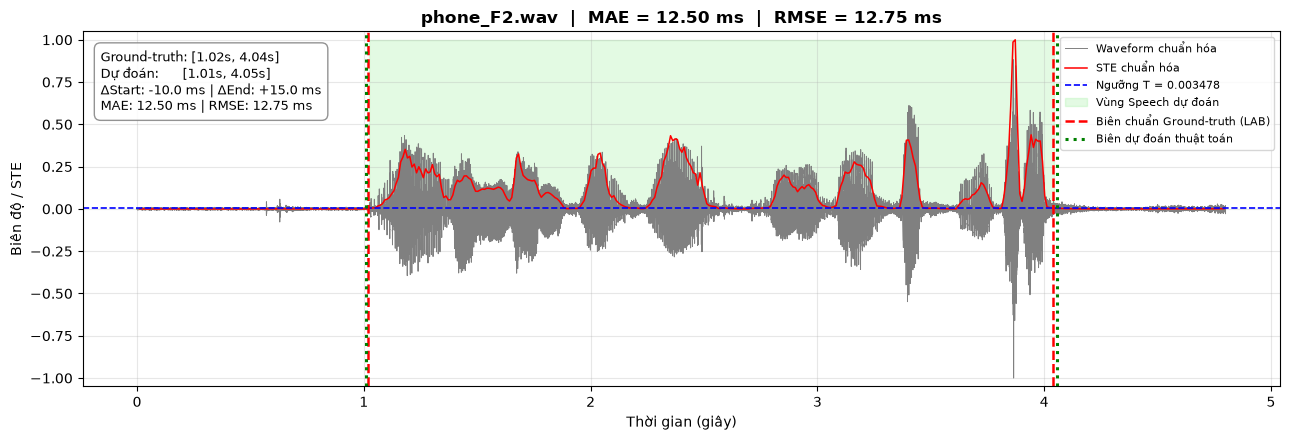

🎵 Audio gốc (phone_F2.wav):


🔊 Đoạn tiếng nói nhận diện [1.01s - 4.05s]:


In [11]:
plot_and_play_test_file(test_results_dict["phone_F2.wav"])

### 12. Thực nghiệm kiểm thử 2: `phone_M2.wav`
Môi trường điện thoại, giọng nam. Hiển thị đồ thị phân đoạn và trình phát audio.

Đã xuất và lưu đồ thị: /home/bim/Projects/DSP_MidTerm/src/TT1/output/mine/phone_M2.png


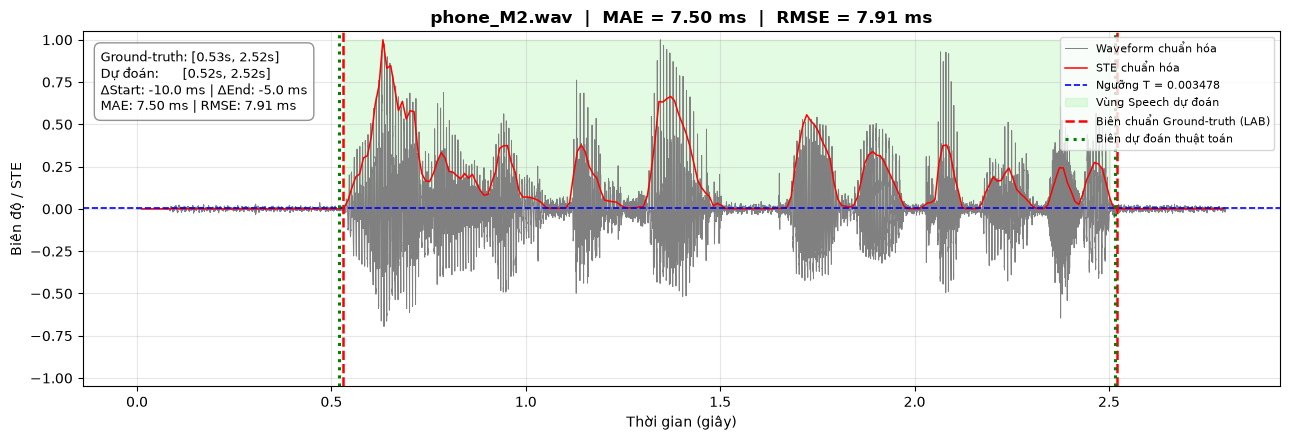

🎵 Audio gốc (phone_M2.wav):


🔊 Đoạn tiếng nói nhận diện [0.52s - 2.52s]:


In [12]:
plot_and_play_test_file(test_results_dict["phone_M2.wav"])

### 13. Thực nghiệm kiểm thử 3: `studio_F2.wav`
Môi trường phòng thu Studio chất lượng cao, giọng nữ. Hiển thị đồ thị phân đoạn và trình phát audio.

Đã xuất và lưu đồ thị: /home/bim/Projects/DSP_MidTerm/src/TT1/output/mine/studio_F2.png


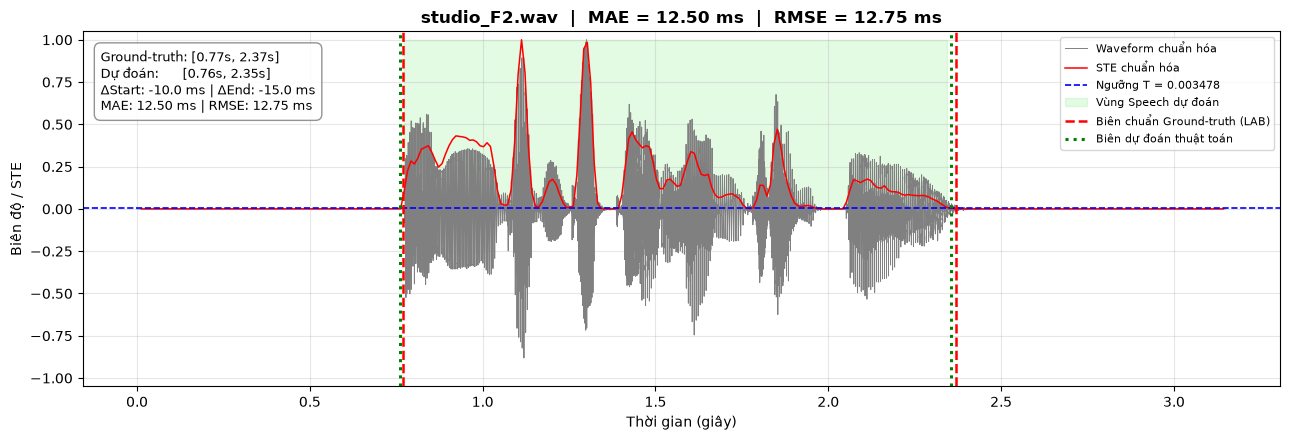

🎵 Audio gốc (studio_F2.wav):


🔊 Đoạn tiếng nói nhận diện [0.76s - 2.35s]:


In [13]:
plot_and_play_test_file(test_results_dict["studio_F2.wav"])

### 14. Thực nghiệm kiểm thử 4: `studio_M2.wav`
Môi trường phòng thu Studio chất lượng cao, giọng nam. Hiển thị đồ thị phân đoạn và trình phát audio.

Đã xuất và lưu đồ thị: /home/bim/Projects/DSP_MidTerm/src/TT1/output/mine/studio_M2.png


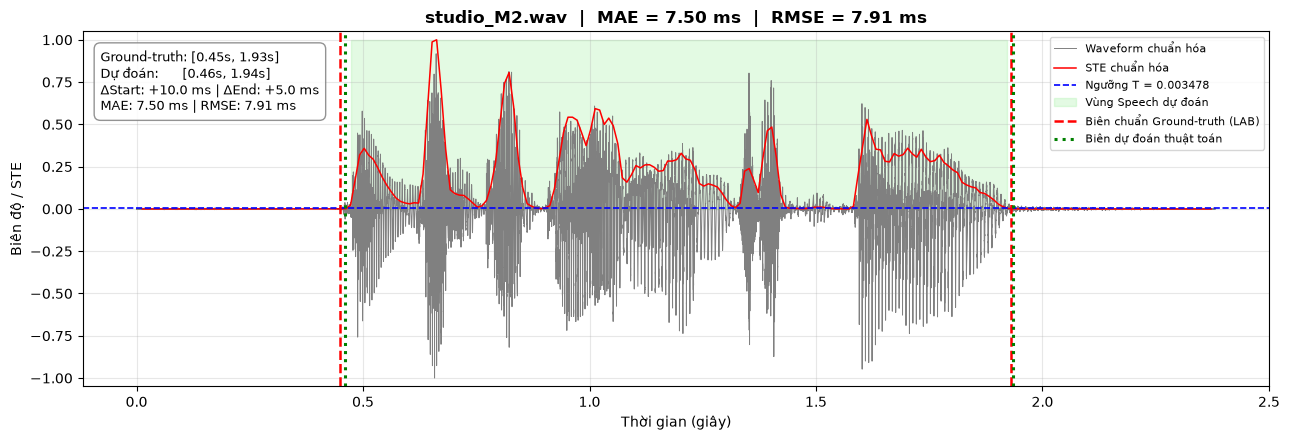

🎵 Audio gốc (studio_M2.wav):


🔊 Đoạn tiếng nói nhận diện [0.46s - 1.94s]:


In [14]:
plot_and_play_test_file(test_results_dict["studio_M2.wav"])